In [1]:
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

# Prepare Data

In [2]:
# load fashion mnist dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

4422102/4422102 [==============================] - 0s 0us/step


In [3]:
# When inputting an image, there must be information about the channel
# Add channel dimension to apply Conv2D
scaled_train = x_train.reshape(-1, 28, 28, 1)

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
scaled_train.shape

(60000, 28, 28, 1)

# Constructing a CNN

1. Detect features in images with convolutional layers
2. Calculate classification probability according to class with dense layer

In [17]:
model = keras.Sequential()

In [18]:
# add convolutional layer
model.add(keras.layers.Conv2D(32, kernel_size = 3, activation = "relu", padding = "same",
                              input_shape = (28, 28, 1)))

- Fashion MNIST image size is (28, 28), same padding is applied, 32 filters are used.
    - The size of the output feature map is (28, 28, 32)

In [19]:
# add pooling layer
model.add(keras.layers.MaxPooling2D(2))

- By applying pooling using a kernel of size (2, 2), the size of the feature map is reduced by half and the depth of the feature map remains the same.
    - The size of the output feature map is (14, 14, 32)

In [20]:
# 2nd convolutional layer with pooling
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(keras.layers.MaxPooling2D(2))

- (14, 14) size with same padding, 64 filters used
    - Size of the output feature map (14, 14, 64)
    
- Pooling using a kernel of size (2, 2)
    - Size of output feature map (7, 7, 64)

In [21]:
# Spread the 3D feature map in a row
# Because the probability is calculated in a dense layer with 10 units
model.add(keras.layers.Flatten())

In [22]:
# Add another dense hidden layer and add dropout to prevent overfitting and improve performance
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))

In [23]:
# output layer
# Multi-classification that classifies 10 classes
model.add(keras.layers.Dense(10, activation='softmax'))

In [24]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 14, 14, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 7, 7, 64)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 3136)              0         
                                                                 
 dense_2 (Dense)             (None, 100)              

- Number of parameters
    - First convolution layer
        - Size of filter: (3, 3, 1)
        - Number of filters: 32
        - 3 * 3 * 1 * 32 + 32 = 320
        
    - Second convolution layer
        - Size of filter: (3, 3, 32)
        - Number of filters: 64
        - 3 * 3 * 32 * 64 + 64 = 18496
        
    - Dense hidden layer
        - In the flatten layer, an array of size (3136,) is passed (7 * 7 * 64)
        - 3136 * 100 + 100 = 313700
        
    - Output layer
        - An array of size (100,) is passed in a dense hidden layer.
        - 100 * 10 + 10 = 1010

# Model Training

- Optimizer: Adam
- Callback functions: ModelCheckpoint, EarlyStopping

In [25]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("./best_cnn_model.h5", save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [26]:
model.compile(optimizer="adam", loss = "sparse_categorical_crossentropy", metrics=["accuracy"])

In [27]:
x_sub, x_val, y_sub, y_val = train_test_split(scaled_train, y_train, stratify = y_train,
                                              test_size = 0.2, random_state = 14)

In [29]:
history = model.fit(x_sub, y_sub, epochs = 20, validation_data = (x_val, y_val),
                    callbacks = [checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 [==============================] - 62s 42ms/step - loss: 0.2433 - accuracy: 0.9068 - val_loss: 0.2666 - val_accuracy: 0.9103
Epoch 2/20
1500/1500 [==============================] - 61s 41ms/step - loss: 0.2349 - accuracy: 0.9141 - val_loss: 0.2613 - val_accuracy: 0.9128
Epoch 3/20
1500/1500 [==============================] - 62s 42ms/step - loss: 0.2246 - accuracy: 0.9159 - val_loss: 0.2815 - val_accuracy: 0.9057
Epoch 4/20
1500/1500 [==============================] - 62s 41ms/step - loss: 0.2196 - accuracy: 0.9178 - val_loss: 0.2787 - val_accuracy: 0.9078


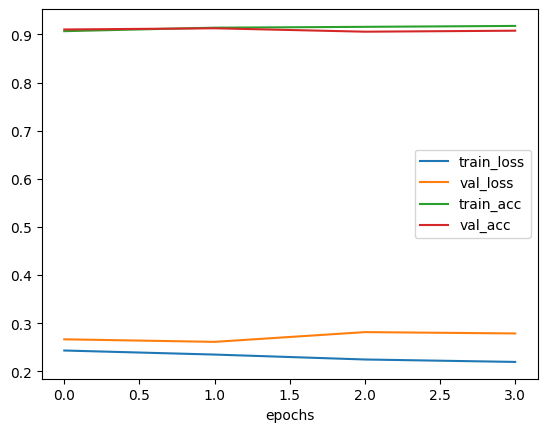

In [30]:
plt.figure()
plt.plot(history.history["loss"], label = "train_loss")
plt.plot(history.history["val_loss"], label = "val_loss")
plt.plot(history.history["accuracy"], label = "train_acc")
plt.plot(history.history["val_accuracy"], label = "val_acc")

plt.xlabel("epochs")
plt.legend()
plt.show()

# Verify model performance

In [31]:
scaled_test = x_test.reshape(-1, 28, 28, 1) / 255

In [32]:
model.evaluate(scaled_test, y_test)

313/313 [==============================] - 4s 11ms/step - loss: 2.2103 - accuracy: 0.2684


[2.210339069366455, 0.26840001344680786]

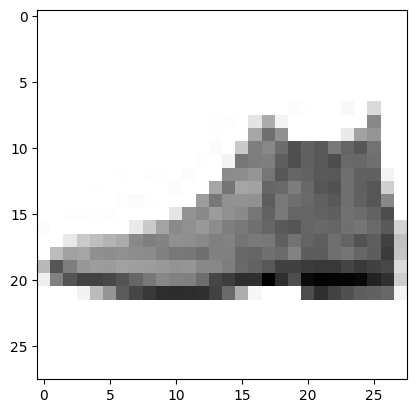

In [33]:
plt.imshow(scaled_test[0].reshape(28, 28), cmap = "gray_r")
plt.show()

In [34]:
preds = model.predict(scaled_test[[0]])

1/1 [==============================] - 0s 131ms/step


In [35]:
print(preds)

[[0.12120995 0.01295863 0.10363789 0.12569486 0.06543484 0.07450925
  0.14148891 0.22040783 0.07564841 0.05900947]]
